> ⚠️ **Preliminary subset check.** This notebook runs on a small 5-record subset (the test set is a single record) to validate the model's pipeline. The numbers here are **volatile and are not the project's results** — the reliable, full-dataset comparison is in **notebook 07** (clean performance) and **notebook 08** (contamination robustness).

# PCA Reconstruction Baseline

This notebook uses PCA reconstruction error as a linear baseline for ECG anomaly detection.

The idea is simple: PCA is fitted on normal beats, then each beat is reconstructed from a lower-dimensional representation. Beats with high reconstruction error are treated as anomalies.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import config
from utils import (
    load_mit_bih_record,
    read_record_names,
    create_beat_dataset,
    split_by_record,
    evaluate_anomaly_detection,
)
from models import PCAReconstructionAnomalyDetector

## Load Records

In [2]:
N_RECORDS = 5

# Paced records are excluded via config.DROP_PACED (see read_record_names).
record_names = read_record_names(config.MIT_BIH_PATH)[:N_RECORDS]

records = []
for record_name in record_names:
    record = load_mit_bih_record(config.MIT_BIH_PATH, record_name)
    if record is not None:
        records.append(record)

print(f"Loaded {len(records)} records: {record_names}")

Loaded 5 records: ['100', '101', '103', '105', '106']


## Create Beat Dataset

In [3]:
dataset = create_beat_dataset(records, normalize=True)

print(dataset.shape)
display(dataset[["record", "sample", "symbol", "label", "label_name"]].head())
display(dataset["label_name"].value_counts())
display(dataset["symbol"].value_counts().head(10))

(10818, 7)


,record,sample,symbol,label,label_name
0,100,370,N,0,normal
1,100,662,N,0,normal
2,100,946,N,0,normal
3,100,1231,N,0,normal
4,100,1515,N,0,normal


label_name
normal     10211
anomaly      607
Name: count, dtype: int64

symbol
N    10211
V      562
A       38
Q        7
Name: count, dtype: int64

In [4]:
X = np.stack(dataset["signal"].values)
y = dataset["label"].values
metadata = dataset.drop(columns=["signal", "label"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10818, 180)
y shape: (10818,)


## Train/Test Split by Record

In [5]:
split = split_by_record(X, y, metadata)

print("Train records:", split["train_records"])
print("Test records:", split["test_records"])
print("Train shape:", split["X_train"].shape)
print("Test shape:", split["X_test"].shape)

print("Train labels:")
display(pd.Series(split["y_train"]).value_counts().rename(index={0: "normal", 1: "anomaly"}))

print("Test labels:")
display(pd.Series(split["y_test"]).value_counts().rename(index={0: "normal", 1: "anomaly"}))

Train records: ['100', '101', '103', '105']
Test records: ['106']
Train shape: (8791, 180)
Test shape: (2027, 180)
Train labels:


normal     8704
anomaly      87
Name: count, dtype: int64

Test labels:


normal     1507
anomaly     520
Name: count, dtype: int64

## Fit PCA Reconstruction Model

PCA is fitted only on normal training beats. This follows a semi-supervised anomaly detection setup: the model learns the structure of normal beats and flags high reconstruction errors as anomalies.

In [6]:
N_COMPONENTS = 8

X_train_normal = split["X_train"][split["y_train"] == 0]

pca_model = PCAReconstructionAnomalyDetector(
    n_components=N_COMPONENTS,
    threshold_percentile=95,
    random_state=config.RANDOM_SEED,
)
pca_model.fit(X_train_normal)

MAX_TEST_PER_CLASS = 150
rng = np.random.default_rng(config.RANDOM_SEED)

test_indices = []
for label in [0, 1]:
    label_indices = np.where(split["y_test"] == label)[0]
    rng.shuffle(label_indices)
    test_indices.extend(label_indices[:MAX_TEST_PER_CLASS])

test_indices = np.array(test_indices)
rng.shuffle(test_indices)

X_test_eval = split["X_test"][test_indices]
y_test_eval = split["y_test"][test_indices]

print("Normal training beats used:", len(X_train_normal))
print("Test beats used:", len(X_test_eval))
display(pd.Series(y_test_eval).value_counts().rename(index={0: "normal", 1: "anomaly"}))
print("PCA components:", N_COMPONENTS)
print("Threshold:", pca_model.threshold)

Normal training beats used: 8704
Test beats used: 300


anomaly    150
normal     150
Name: count, dtype: int64

PCA components: 8
Threshold: 0.0008238842704431334


## Evaluate

In [7]:
scores = pca_model.anomaly_score(X_test_eval)
y_pred = pca_model.predict(X_test_eval)

results = evaluate_anomaly_detection(y_test_eval, y_pred, scores)
results

{'confusion_matrix': [[11, 139], [0, 150]],
 'precision': 0.5190311418685121,
 'recall': 1.0,
 'f1': 0.683371298405467,
 'roc_auc': 0.9998222222222223,
 'pr_auc': 0.9998268398268401}

### Metric Interpretation

PCA produces a strong **ranking** score on this subset: the ROC-AUC and PR-AUC are very high (close to 1.0), meaning normal and anomalous beats are well separated by reconstruction error.

The binary decision, however, depends heavily on the threshold. At the default 95th percentile the threshold is too low for the test record: precision is around 0.5 with recall near 1.0, i.e. almost every beat is flagged as anomalous. The score is good; the operating point is not yet.

## Threshold Sensitivity

In [8]:
threshold_results = []
train_scores = pca_model.anomaly_score(X_train_normal)

for percentile in [95, 97, 98, 99, 99.5, 99.9]:
    threshold = np.percentile(train_scores, percentile)
    y_pred_threshold = (scores > threshold).astype(int)
    metrics = evaluate_anomaly_detection(y_test_eval, y_pred_threshold, scores)

    threshold_results.append({
        "percentile": percentile,
        "threshold": threshold,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "roc_auc": metrics["roc_auc"],
        "pr_auc": metrics["pr_auc"],
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

,percentile,threshold,precision,recall,f1,roc_auc,pr_auc
0,95.0,0.000824,0.519031,1.000000,0.683371,0.999822,0.999827
1,97.0,0.001559,0.943396,1.000000,0.970874,0.999822,0.999827
2,98.0,0.002504,1.000000,0.973333,0.986486,0.999822,0.999827
3,99.0,0.005127,1.000000,0.540000,0.701299,0.999822,0.999827
4,99.5,0.007936,1.000000,0.426667,0.598131,0.999822,0.999827
5,99.9,0.016012,1.000000,0.080000,0.148148,0.999822,0.999827


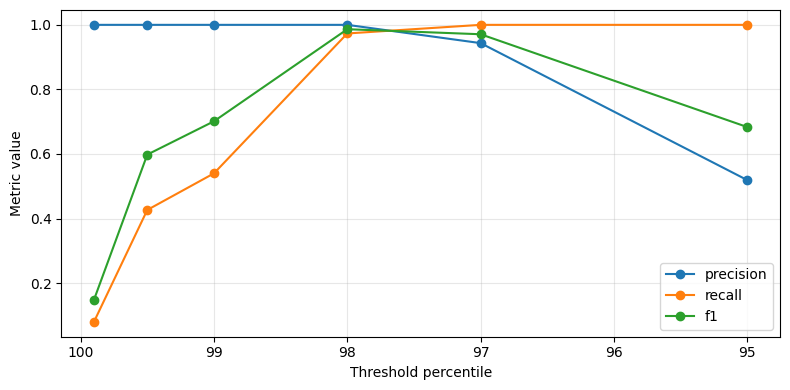

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["percentile"], threshold_df["precision"], marker="o", label="precision")
plt.plot(threshold_df["percentile"], threshold_df["recall"], marker="o", label="recall")
plt.plot(threshold_df["percentile"], threshold_df["f1"], marker="o", label="f1")
plt.gca().invert_xaxis()
plt.xlabel("Threshold percentile")
plt.ylabel("Metric value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Threshold Discussion

PCA needs a higher threshold than the default 95th percentile on this subset. At 95th it flags almost everything (precision ~0.5), while around the 98th percentile it reaches an excellent trade-off (precision ~1.0 with recall ~0.97); beyond that, recall drops sharply.

This sweet spot above the default suggests a record-level distribution shift: even normal beats from the test record can have larger reconstruction error than normal beats from the training records. PCA is sensitive to this patient-level variation, which is an important limitation to discuss.

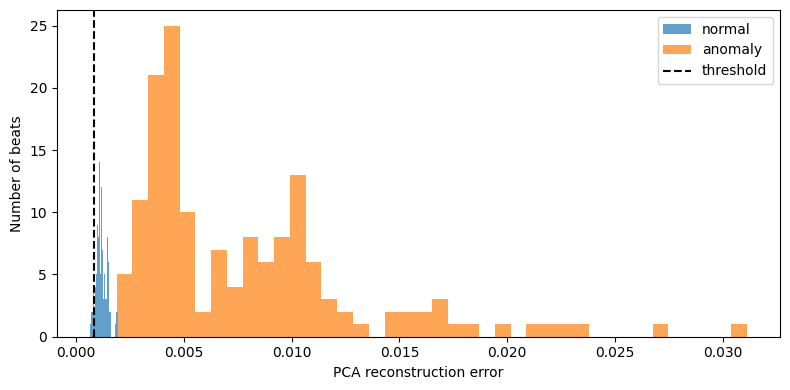

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(scores[y_test_eval == 0], bins=40, alpha=0.7, label="normal")
plt.hist(scores[y_test_eval == 1], bins=40, alpha=0.7, label="anomaly")
plt.axvline(pca_model.threshold, color="black", linestyle="--", label="threshold")
plt.xlabel("PCA reconstruction error")
plt.ylabel("Number of beats")
plt.legend()
plt.tight_layout()
plt.show()

## Note on Cross-Model Comparison

A proper comparison across ARMA, PCA, and the neural models is deferred to the final full-dataset experiment. The per-notebook results so far are computed on a small subset whose **test set is a single record (106)**, which makes them volatile: for example, ARMA's apparent quality changes drastically depending on which records fall in the subset. These notebooks validate each model's pipeline; the reliable comparison will use all records under one protocol.

## Interpretation Notes

- PCA is a linear reconstruction baseline, interpretable as a simple linear autoencoder. It bridges classical methods and neural autoencoders.
- On this subset the reconstruction error separates the classes very well (high ROC-AUC/PR-AUC), but the default 95th-percentile threshold is too low and flags almost every test beat as anomalous.
- This points to a record-level distribution shift: normal beats from the test record can have higher reconstruction error than normal training beats.
- **Caveat:** the test set is a single record (106), so these numbers are volatile and preliminary; the full-dataset experiment is needed for a reliable read.
- PCA looking this strong here is a property of the subset, not a preview of the final result: on the full dataset (notebook 07) its ROC-AUC is still competitive, but its PR-AUC — the more informative metric on this imbalanced problem — turns out to be the *lowest* among the reconstruction models. The later deep models are worth their extra complexity once evaluated on the metric that actually matters here.